In [6]:
import numpy as np
import scipy as sp 
from pprint import pprint
from matplotlib import pyplot as plt

import morph_analyses as m

%load_ext autoreload
%autoreload 2

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Mouse information

Information about each mouse is stored in morph_analyses.mouse_metadata . Details of each imaging session for each mouse and for each group of mice are saved in nested dictionaries. 

- 'Rare Morph' sessions are saved in morph_analyses.mouse_metadata.rare_sessions
- 'Frequent Morph' sessions are saved in morph_analyses.mouse_metadata.frequent_sessions
- 'Frequent Morph with Decision' (Extended Data Fig 10) sessions are saved in morph_analyses.mouse_metadata.frequent_w_decision_sessions

Each mouse's metadata and each imaging session's metadata are saved in a dictionary inside each of the dictionaries listed above. Additionally, sessions are broken up by 'training sessions' (first 7 days of behavior in the VR task) or 'test sessions' (days 8-N, number of sessions variable across mice). Information about VR only sessions is not included in this repository. 

In [ ]:
# grab an example mouse
# mouse = m.mouse.metadata.rare_mice[0]
mouse = m.mouse_metadata.frequent_mice[1] 
# mouse = m.mouse.metadata.frequent_w_decision_mice[0]
print(f'mouse: {mouse}')

mouse: F2


In [65]:
sess_deets = m.mouse_metadata.frequent_sessions[mouse]['training_sessions'][1]
pprint(sess_deets)

{'date_str': '10_04_2019',
 'datetime': datetime.datetime(2019, 4, 10, 0, 0),
 'day': 3,
 'scan': 12,
 'scene': 'TwoTower_foraging',
 'session': 3}


In [66]:
sess = m.sess.CA1MorphSession.from_nwb(mouse, 'training', sess_deets['day'])

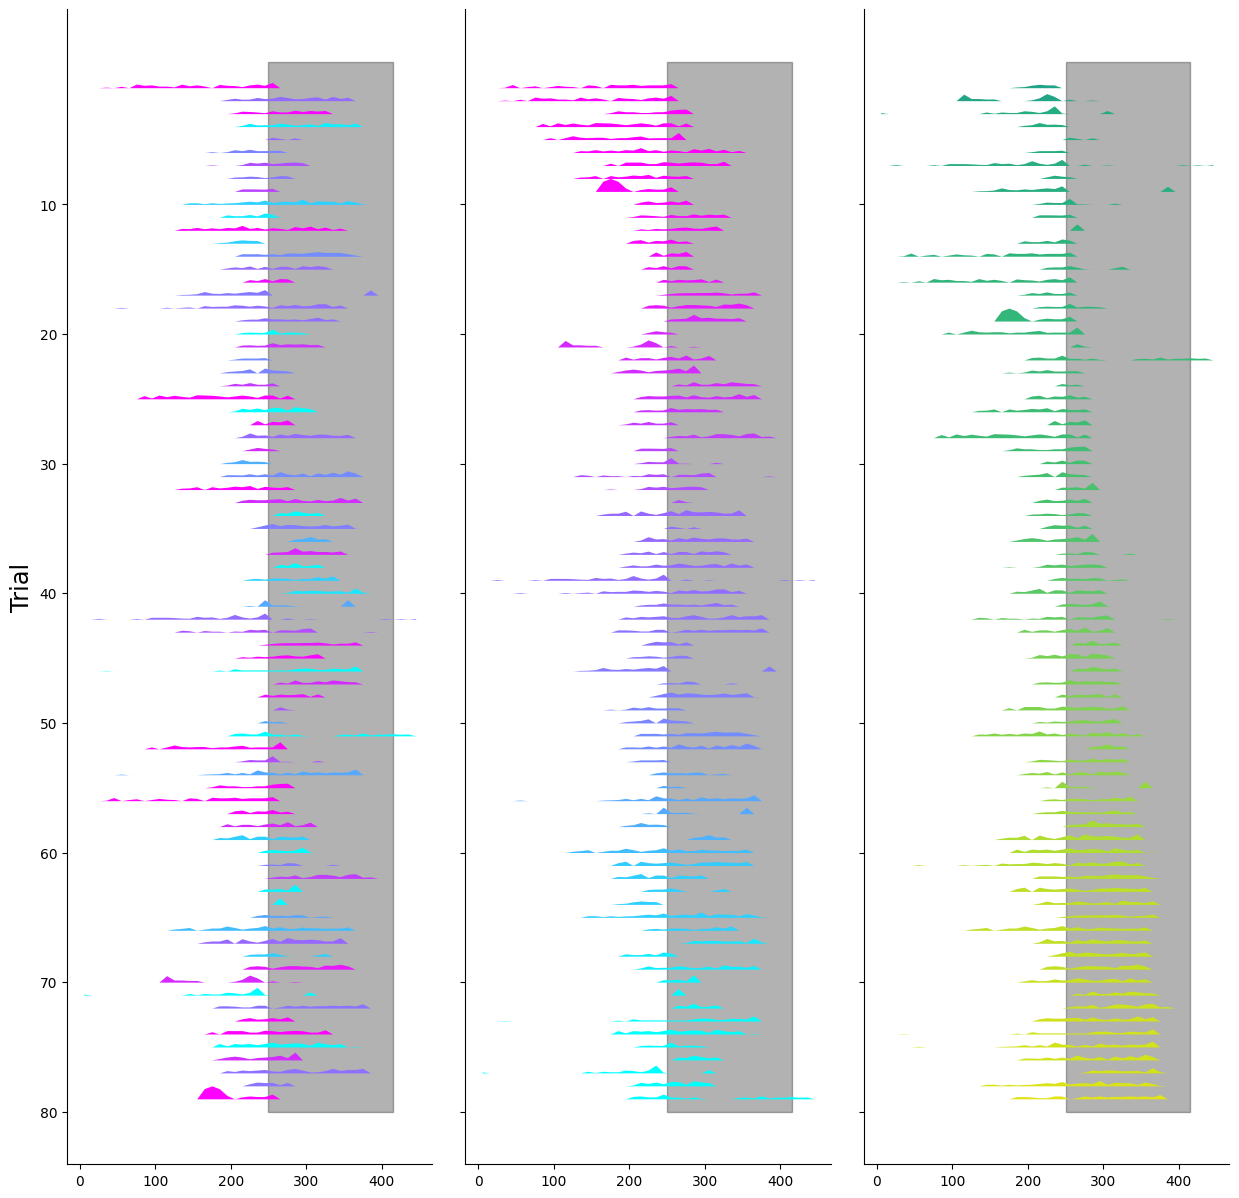

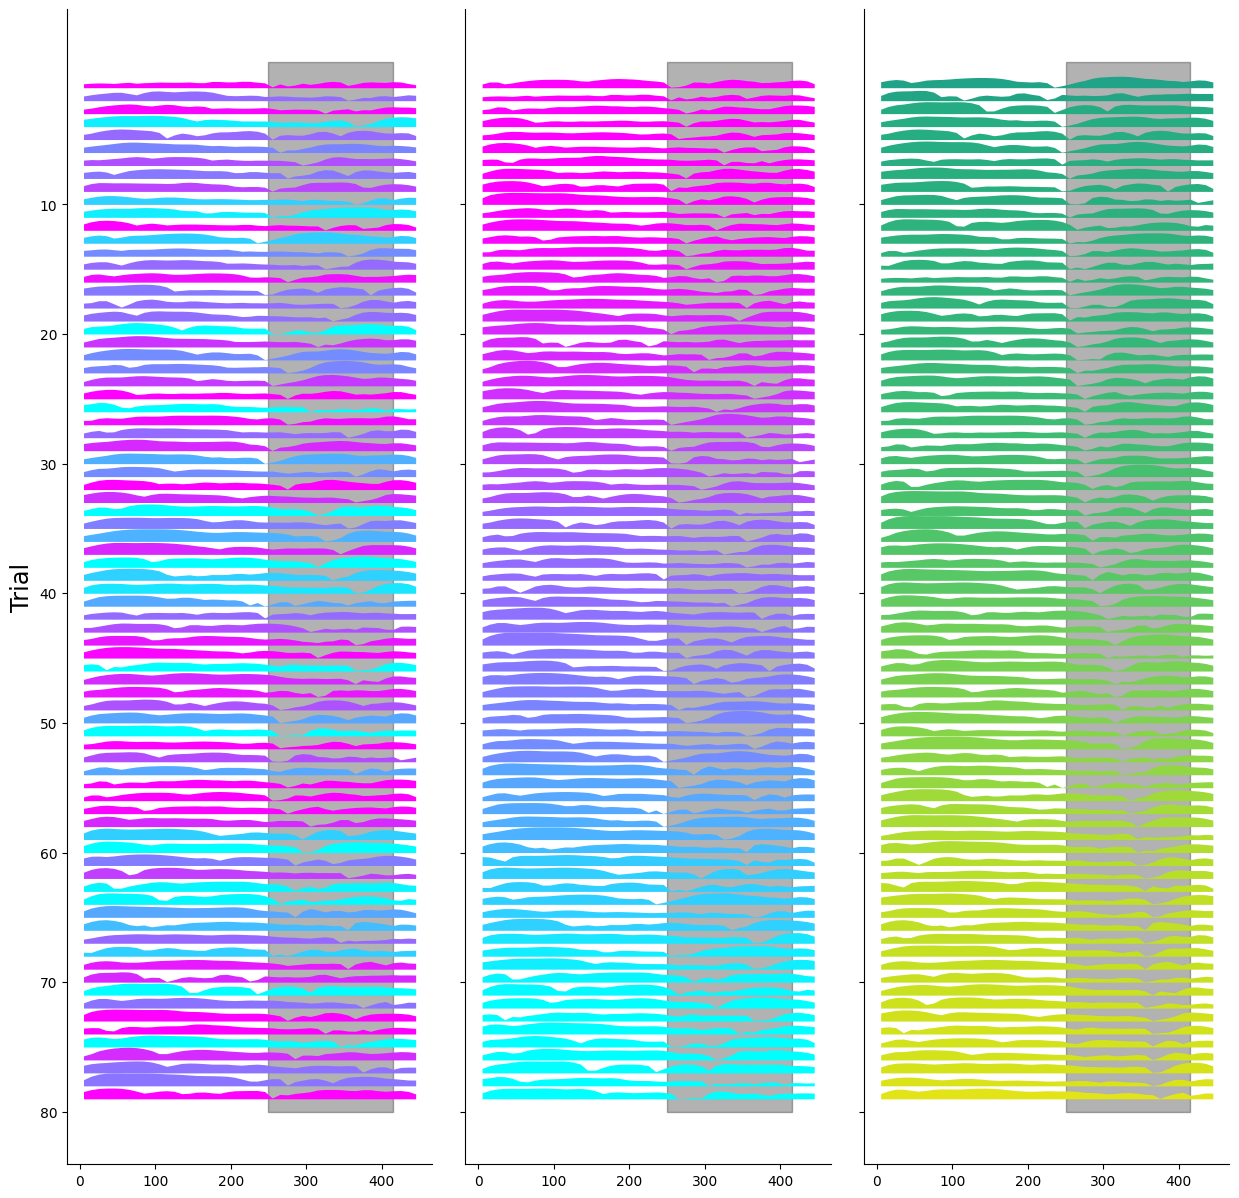

In [67]:
# licking and running behavior
effMorph = sess.trial_info['effective_morph']
reward_pos = sess.trial_info['rzone_entry']
reward_pos[np.isnan(reward_pos)]= 480


max_pos = np.copy(sess.trial_info['max_pos'])
max_pos[max_pos>440]=np.nan


lick_trial_mat = sess.trial_matrices['licks']
centers = sess.trial_matrices['bin_centers']
eff_morph = sess.trial_info['effective_morph']
f_lick, axarr_lick = m.behavior.behavior_raster_foraging(lick_trial_mat/np.nanmax(lick_trial_mat.ravel()),
                                                    centers,eff_morph,reward_pos/390.,smooth=False)

speed_trial_mat = sess.trial_matrices['speed']
f_speed,axarr_speed = m.behavior.behavior_raster_foraging(speed_trial_mat/np.nanmax(speed_trial_mat.ravel()),
                                                    centers,eff_morph,reward_pos/390.,smooth=False)

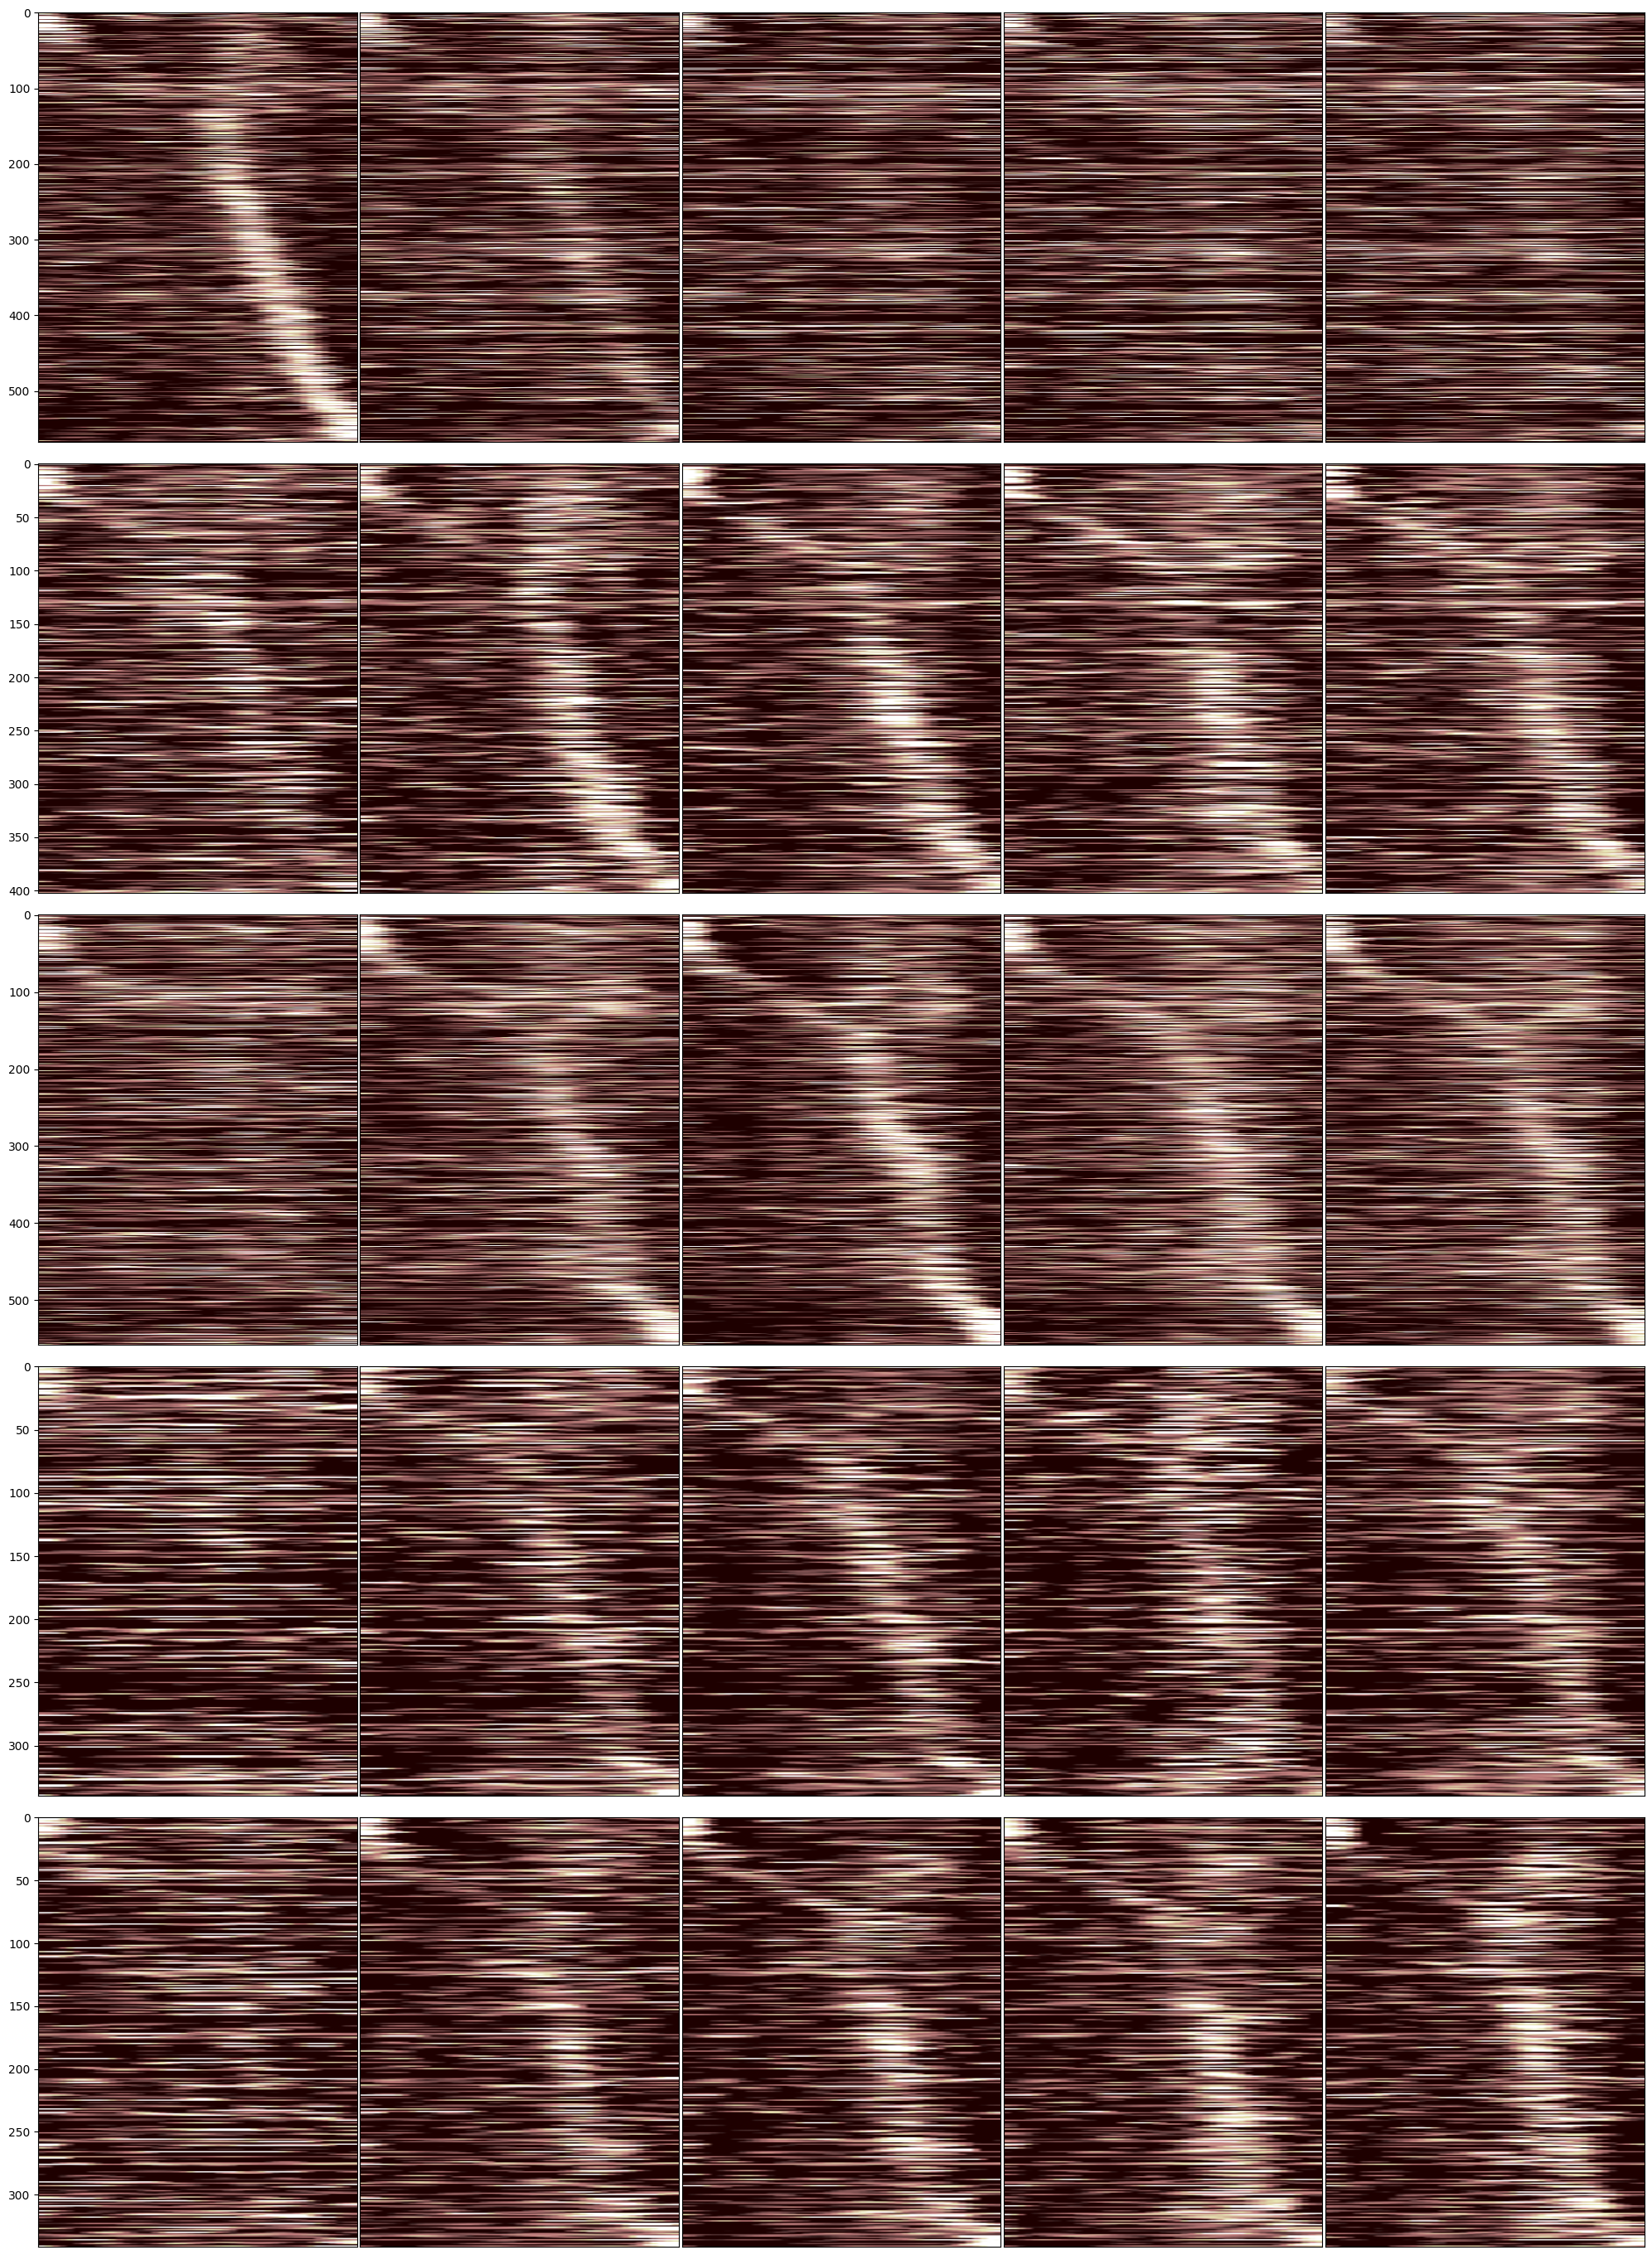

In [68]:
spks_morph_dict = m.utilities.trial_type_dict(sess.trial_matrices['spks_norm'], sess.trial_info['morphs'])
# spks_morph_dict.keys()

f_pc, ax_pc,PC_dict = m.place_cell_analysis.plot_placecells(spks_morph_dict, sess.place_cell_info['masks'])

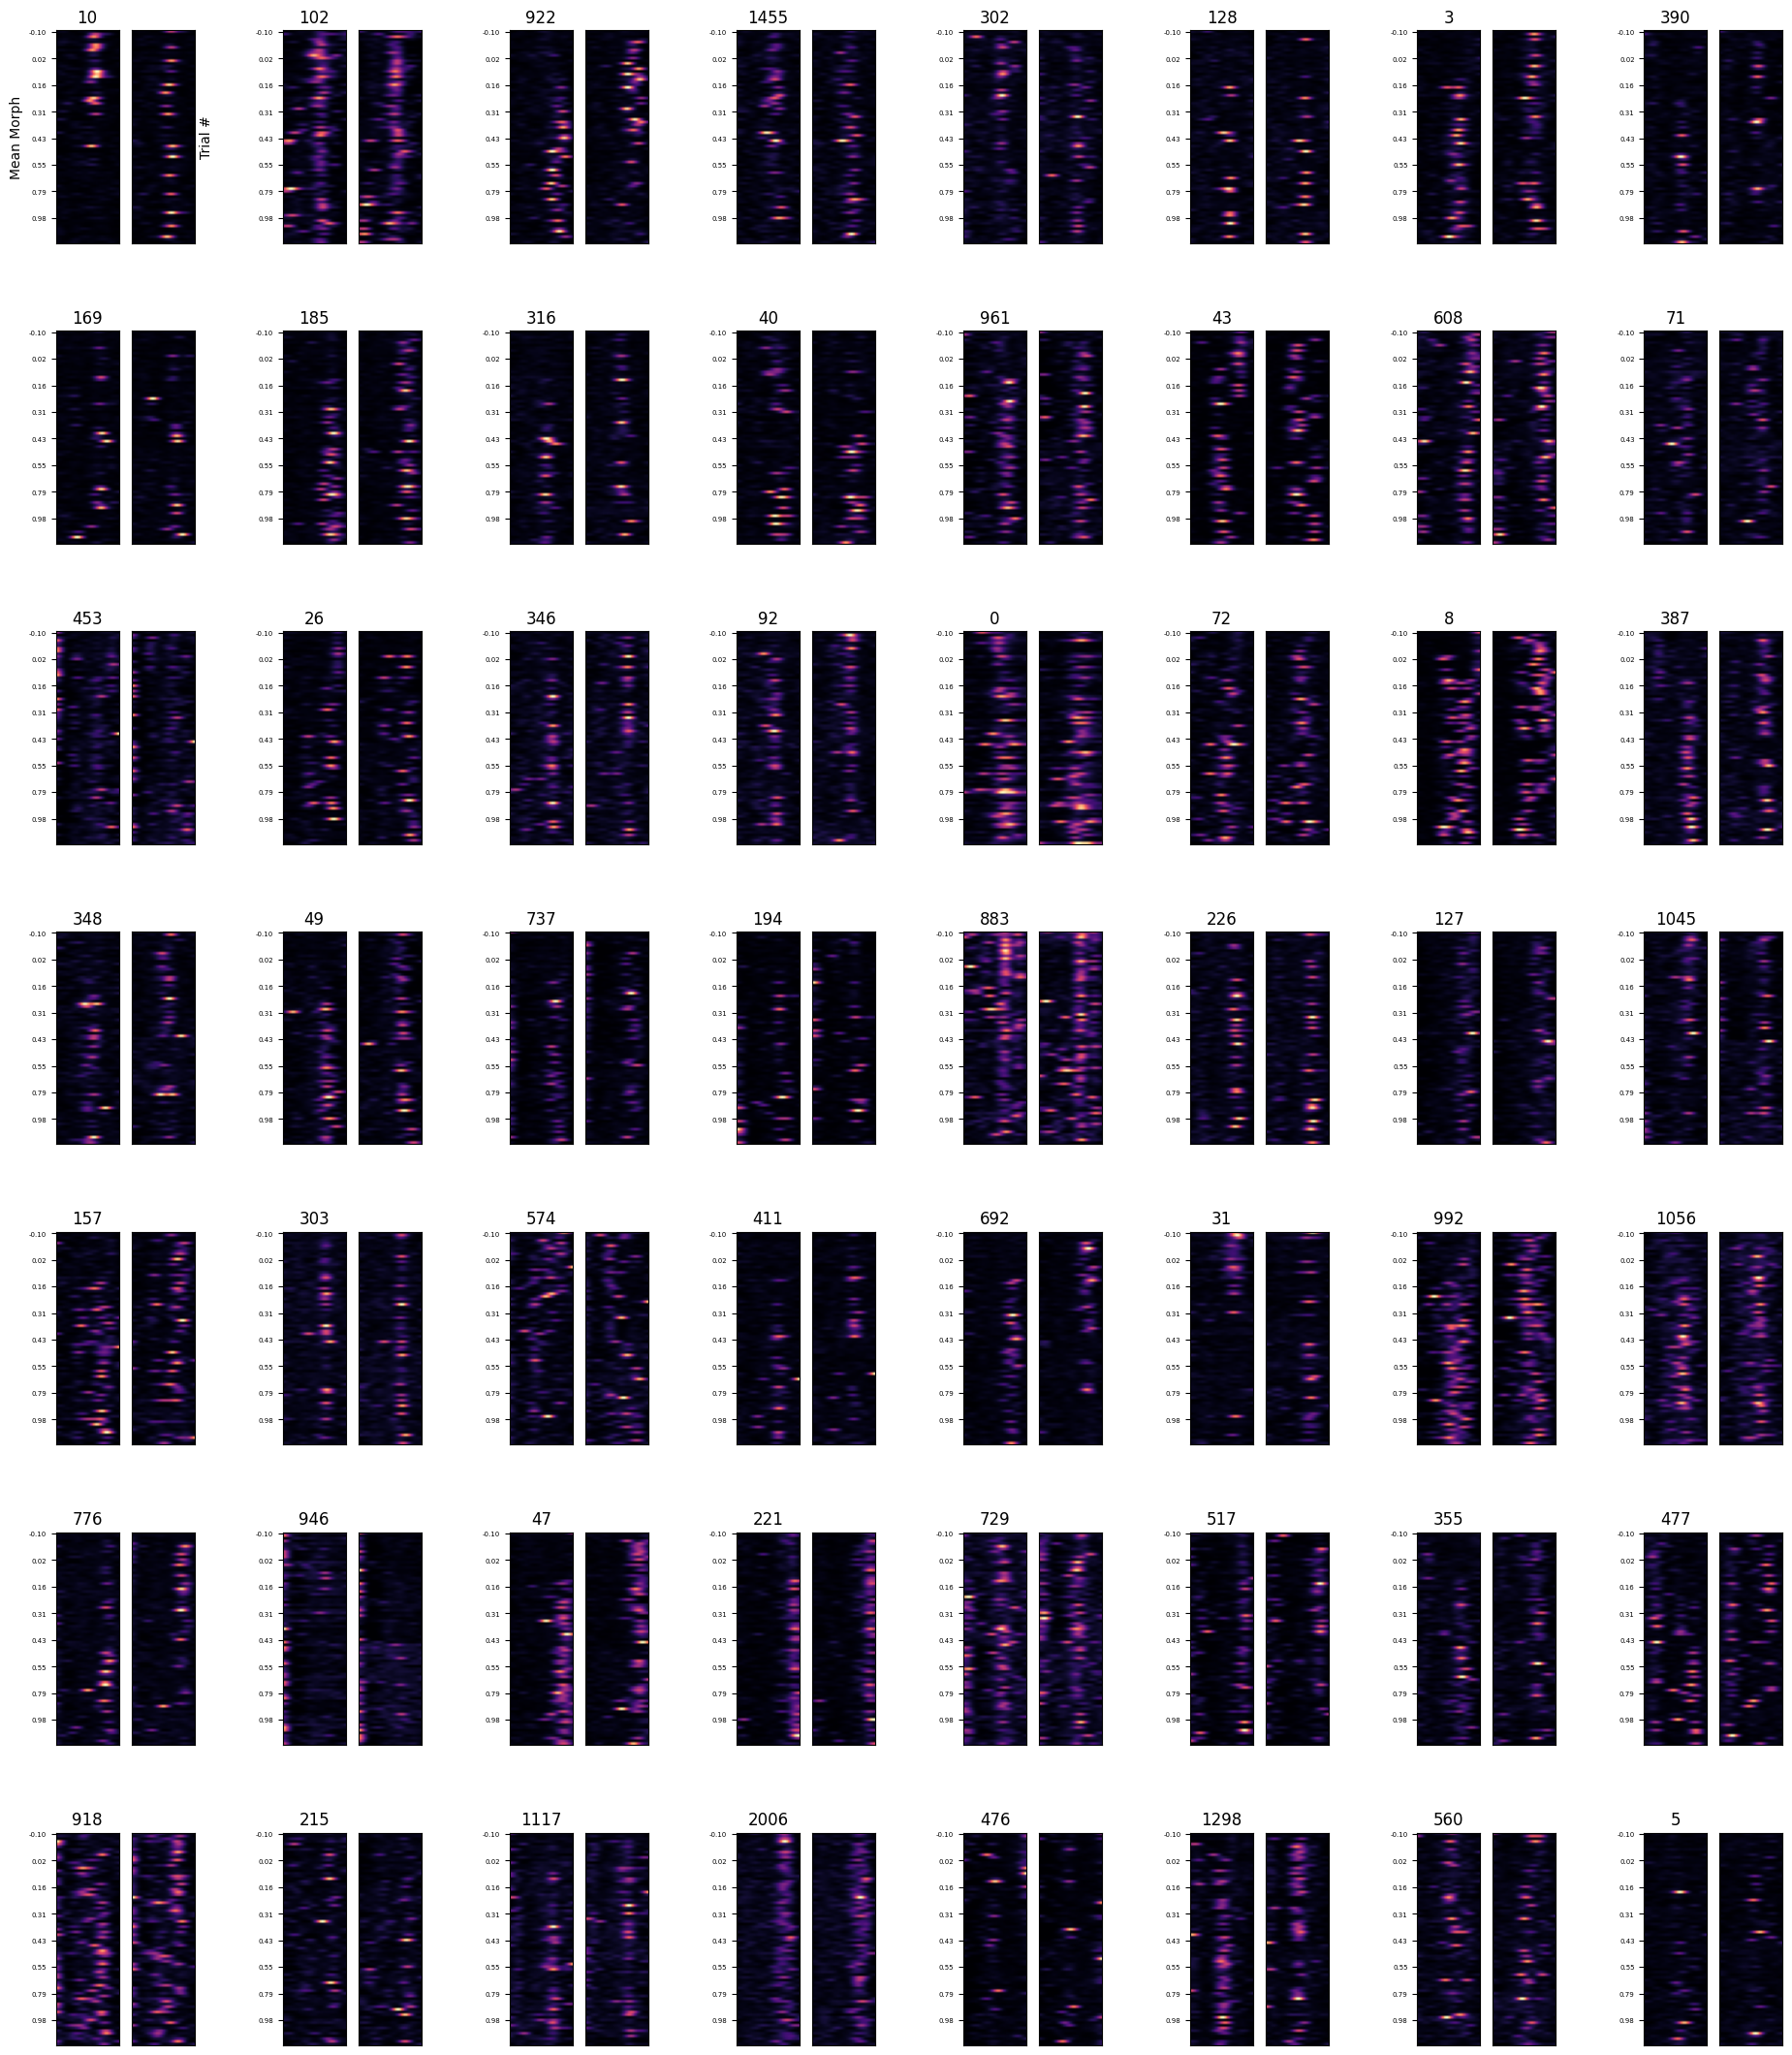

In [69]:
# single cell plots
f_singlecells = m.place_cell_analysis.plot_top_cells(
    sess.trial_matrices['spks_norm'],
    sess.place_cell_info['masks'],
    sess.place_cell_info['SI'], 
    sess.trial_info['effective_morph'],
    maxcells=56,
    )

0
9.977671023269693
12.25842879678618
5.339554199527731
5.628436781201744
5.137840346847149
5.418472161765688
6.079576044424726
4.795976413728513


Text(0, 0.5, '$SF$')

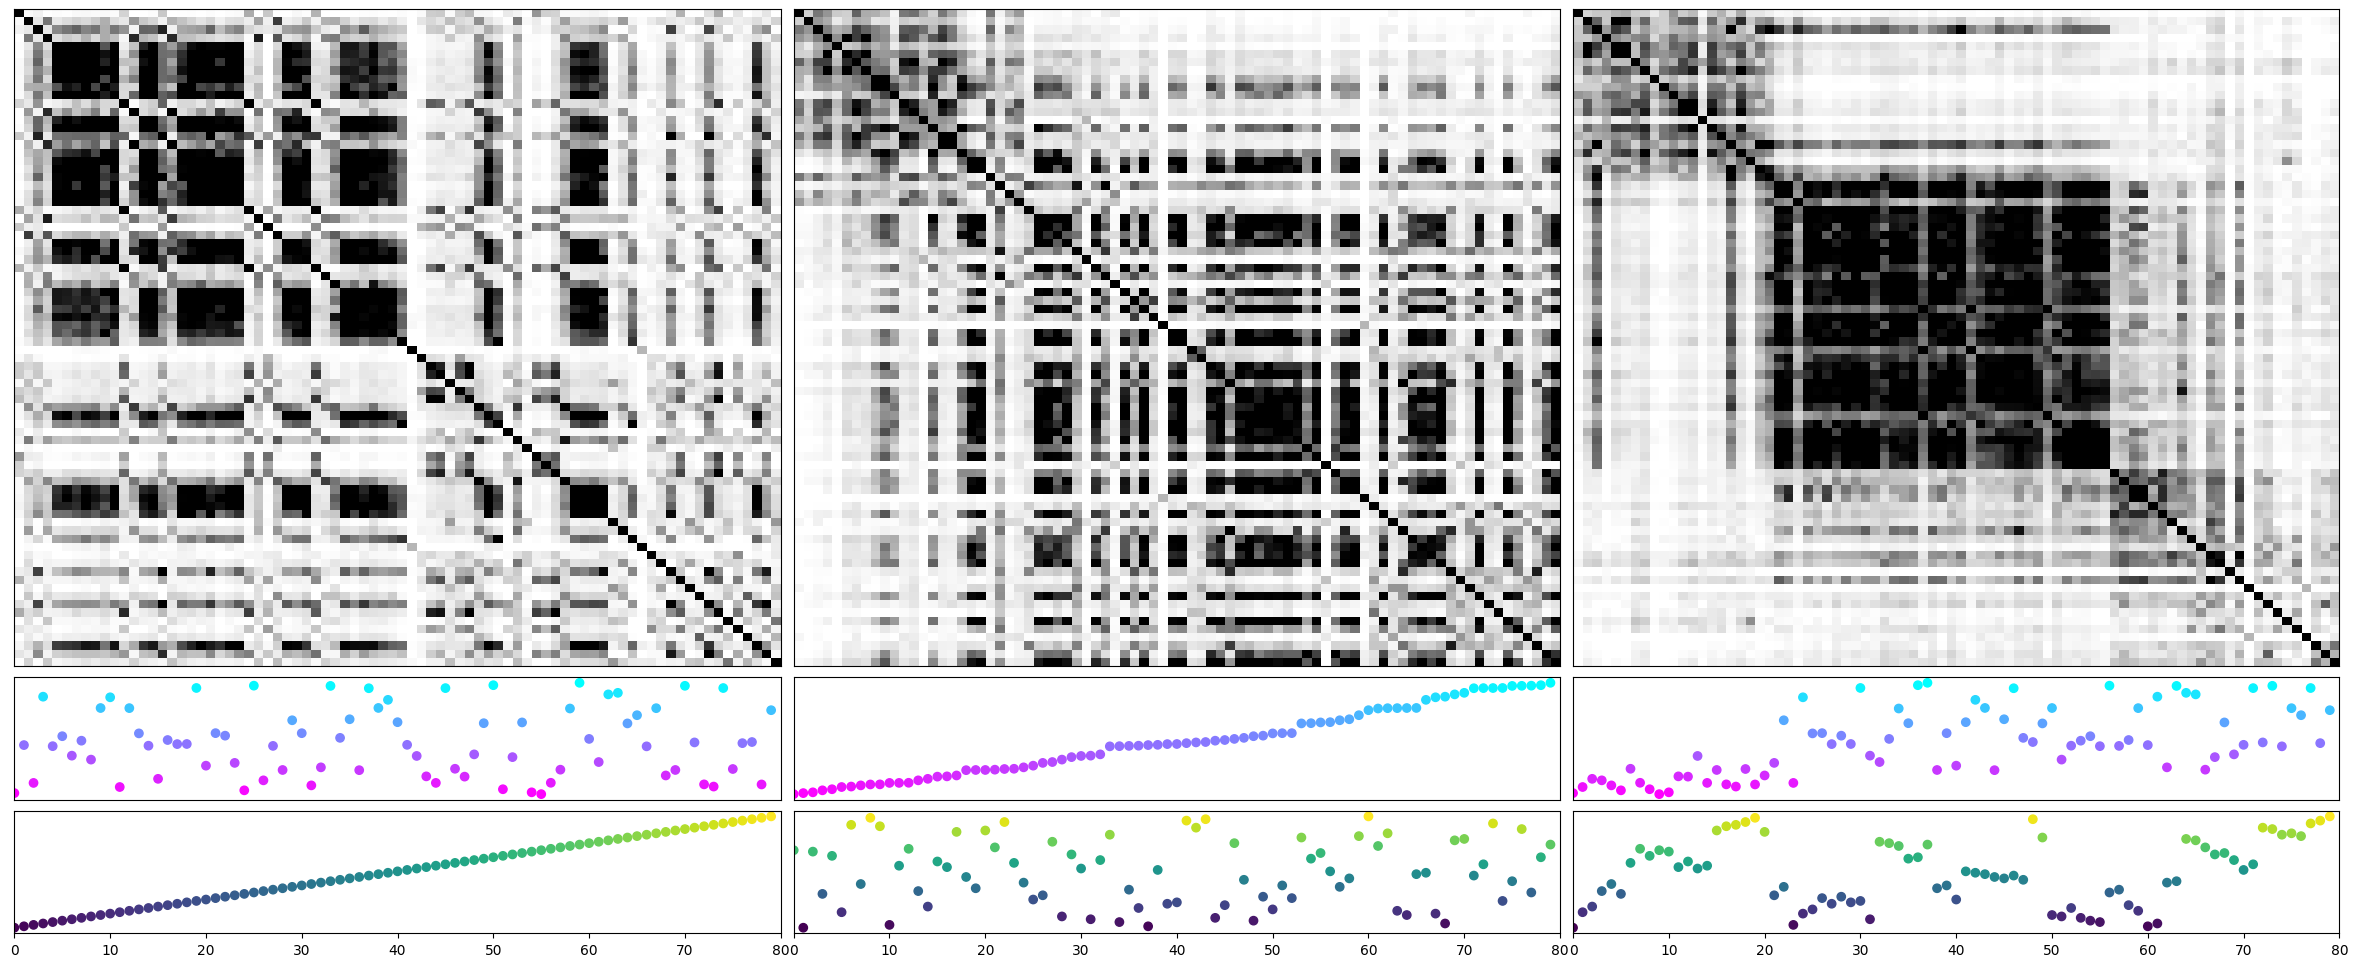

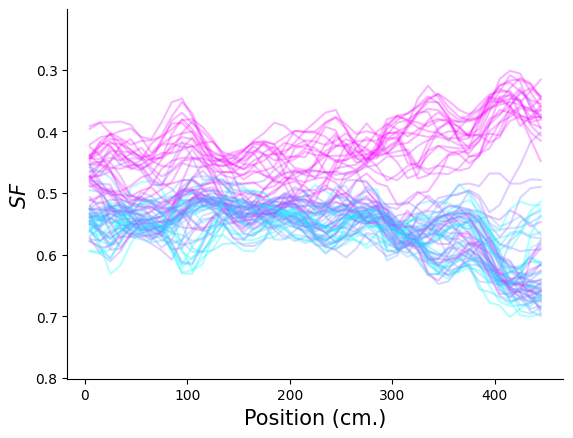

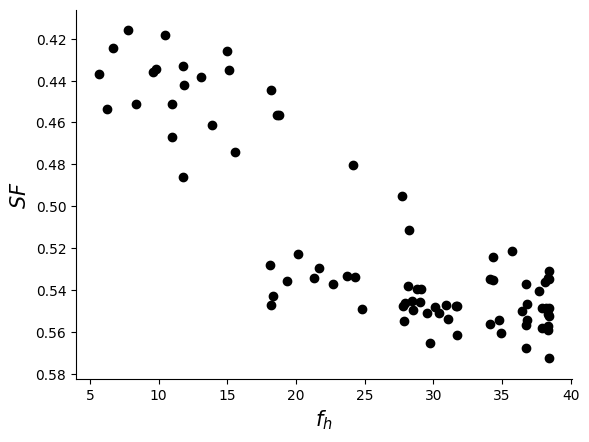

In [70]:
# trial x trial similarity matrix
spks_trial_mat = np.copy(sess.trial_matrices['spks_norm'])
spks_trial_mat[np.isnan(spks_trial_mat)]=1E-3
# S_trial_mat is trials x positions x neurons
spks_trial_mat = sp.ndimage.gaussian_filter1d(spks_trial_mat,1,axis=1) # smooth position by 1 bin

#flatten to be trial x positions*neurons
spks_tmat = np.reshape(spks_trial_mat,[spks_trial_mat.shape[0],-1])
# divide trials by l2-norm
spks_tmat = spks_tmat/np.linalg.norm(spks_tmat,ord=2,axis=-1)[:,np.newaxis]
# outer product give trial x trial cosine similarity
spks_t_rmat = np.matmul(spks_tmat,spks_tmat.T)
print((spks_t_rmat<0).sum())
f_stsm,axtup_stsm = m.similarity_matrix_analysis.plot_trial_simmat(spks_t_rmat,sess.trial_info)

# similarity fraction vs position
rtsf = m.utilities.rt_similarity_fraction(spks_trial_mat,sess.trial_info,sigma=0)
f, rtsf_ax = plt.subplots()
for t in range(rtsf.shape[0]):
    rtsf_ax.plot(np.arange(5,450,10),rtsf[t,:],alpha=.3,c=plt.cm.cool(1-sess.trial_info['effective_morph'][t]))
            
rtsf_ax.spines['top'].set_visible(False)
rtsf_ax.spines['right'].set_visible(False)
rtsf_ax.set_ylim([np.nanmax(rtsf.ravel())+.1,np.nanmin(rtsf.ravel())-.1])
rtsf_ax.set_xlabel("Position (cm.)",fontsize=15)
rtsf_ax.set_ylabel("$SF$",fontsize=15)

# summary similarity fraction
sf = m.utilities.similarity_fraction(spks_trial_mat,sess.trial_info)
f, sf_ax = plt.subplots()
sf_ax.scatter(m.unity_transforms.xfreq(sess.trial_info['effective_morph']),sf,color='black') #,c=plt.cm.cool(1-effMorph))
sf_ax.set_ylim([np.nanmax(sf)+.01,np.nanmin(sf)-.01])
sf_ax.spines['top'].set_visible(False)
sf_ax.spines['right'].set_visible(False)
sf_ax.set_xlabel("$f_h$",fontsize=15)
sf_ax.set_ylabel("$SF$",fontsize=15)